In [1]:
import pandas as pd
import numpy as np
from matplotlib_venn import venn2,venn3
import seaborn as sns
import matplotlib.pyplot as plt
import gpplot as gpp
from zipfile import ZipFile
gpp.set_aesthetics(context='paper')

In [5]:
zip_file = ZipFile('../../Data/CRISPickRuns/sgRNA_design_9606_GRCh38_SpyoCas9_CRISPRi_RS3i-Chen2013_Ensembl_20250806.txt.zip')
gw_rs3i_designs = pd.read_table(zip_file.open('sgRNA_design_9606_GRCh38_SpyoCas9_CRISPRi_RS3i-Chen2013_Ensembl_20250806.txt'))

/var/folders/mj/lhpd16ys0cx2wkbhm7s0nfcm0000gp/T/ipykernel_10834/2482730477.py:2: DtypeWarning: Columns (24,25) have mixed types. Specify dtype option on import or set low_memory=False.
  gw_rs3i_designs = pd.read_table(zip_file.open('sgRNA_design_9606_GRCh38_SpyoCas9_CRISPRi_RS3i-Chen2013_Ensembl_20250806.txt'))


In [94]:
seed_lengths = [8,9,10,11,12]
frac_filtered = []
rs3i_df_list = []
total = gw_rs3i_designs['sgRNA Sequence'].nunique()
for n in seed_lengths:
    gw_rs3i_designs['seed_seq'] = gw_rs3i_designs['sgRNA Sequence'].str[-n:]
    gw_rs3i_designs['num_genes_with_seed'] = gw_rs3i_designs.groupby('seed_seq')['Target Gene ID'].transform('nunique')
    num_filtered = gw_rs3i_designs[gw_rs3i_designs['num_genes_with_seed'] > 1]['sgRNA Sequence'].nunique()
    frac_filtered.append(num_filtered/total)

    #rs3i dist
    no_seed_match_designs = gw_rs3i_designs[gw_rs3i_designs['num_genes_with_seed'] == 1].copy()
    no_seed_match_designs['filtered_pick_order'] = no_seed_match_designs.groupby('Target Gene ID')['Pick Order'].transform('rank',method='first')
    rs3i_df = pd.DataFrame({'RS3i':no_seed_match_designs[no_seed_match_designs['filtered_pick_order'] < 4]['On-Target Efficacy Score'],
                            'seed_length':n})
    rs3i_df_list.append(rs3i_df)

In [85]:
frac_filtered

[0.9980435706386471,
 0.9678254799025546,
 0.8517613802823593,
 0.6486404630502086,
 0.4264026245846299]

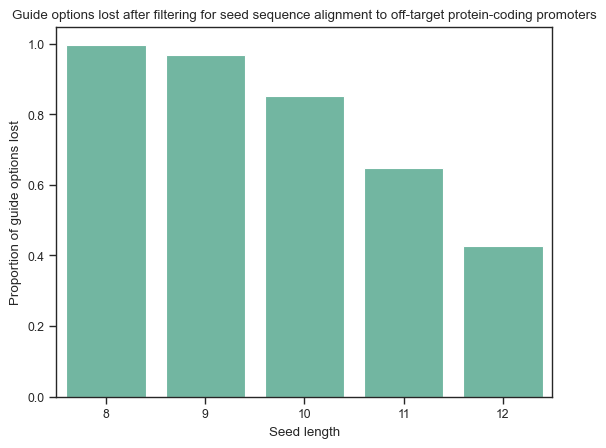

In [122]:
sns.barplot(x = seed_lengths, y = frac_filtered)
plt.xlabel('Seed length')
plt.ylabel('Proportion of guide options lost')
plt.title('Guide options lost after filtering for seed sequence alignment to off-target protein-coding promoters')
gpp.savefig("../../Figures/Figure 5/seed_length_vs_guides_filtered.png",dpi=300, bbox_inches = 'tight')

In [95]:
total_rs3i_df = pd.DataFrame({'RS3i':gw_rs3i_designs[gw_rs3i_designs['Pick Order'] < 4]['On-Target Efficacy Score'],
                              'seed_length':'unfiltered'})
rs3i_df_list.append(total_rs3i_df)

In [104]:
total_rs3i_df

,RS3i,seed_length
0,1.7330,unfiltered
1,1.6820,unfiltered
2,1.6170,unfiltered
73,1.7030,unfiltered
74,1.6520,unfiltered
...,...,...
1594839,1.2840,unfiltered
1594840,0.8728,unfiltered
1594867,1.6000,unfiltered
1594868,1.3570,unfiltered


In [96]:
rs3i_df_combined = pd.concat(rs3i_df_list)
rs3i_df_combined

,RS3i,seed_length
865,1.4110,8
1631,0.8037,8
1633,0.7329,8
2156,0.4789,8
2361,0.1634,8
...,...,...
1594839,1.2840,unfiltered
1594840,0.8728,unfiltered
1594867,1.6000,unfiltered
1594868,1.3570,unfiltered


In [124]:
rs3i_df_combined['n_guide'] = rs3i_df_combined.groupby('seed_length')['RS3i'].transform('count')
ss_df = rs3i_df_combined[['seed_length','n_guide']].drop_duplicates().reset_index(drop=True)
ss_df

,seed_length,n_guide
0,8,2755
1,9,34267
2,10,55831
3,11,57382
4,12,57709
5,unfiltered,60348


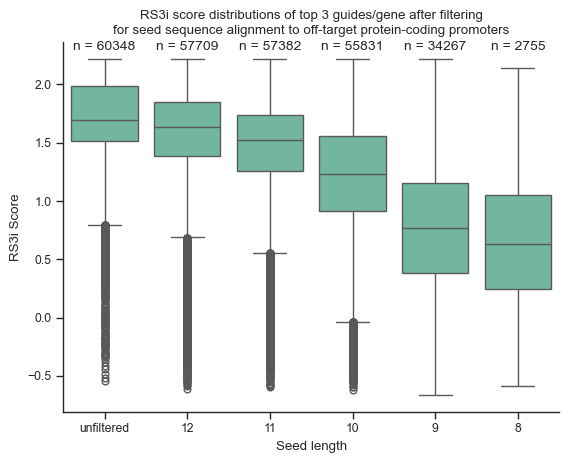

In [125]:
sns.boxplot(data = rs3i_df_combined, x = 'seed_length', y = 'RS3i', order = ['unfiltered',12,11,10,9,8])
for i,row in ss_df.iterrows():
    num = 'n = ' + str(row['n_guide'])
    text = plt.text(5-i, 2.3, num, fontsize=10,ha='center')

sns.despine()
plt.xlabel('Seed length')
plt.ylabel('RS3i Score')
plt.title('RS3i score distributions of top 3 guides/gene after filtering\nfor seed sequence alignment to off-target protein-coding promoters')
gpp.savefig("../../Figures/Figure 5/seed_length_vs_picked_rs3i.png",dpi=300, bbox_inches = 'tight')

In [62]:
gw_rs3i_designs['seed_seq'] = gw_rs3i_designs['sgRNA Sequence'].str[-8:]
gw_rs3i_designs['num_genes_with_seed'] = gw_rs3i_designs.groupby('seed_seq')['Target Gene ID'].transform('nunique')
guide_options_per_gene = gw_rs3i_designs.groupby('Target Gene ID')['sgRNA Sequence'].nunique().reset_index().rename(columns = {'sgRNA Sequence':'num_guides_original'})

In [63]:
no_seed_match_designs = gw_rs3i_designs[gw_rs3i_designs['num_genes_with_seed'] == 1].copy()
guide_options_after_filtering = no_seed_match_designs.groupby('Target Gene ID')['sgRNA Sequence'].nunique().reset_index().rename(columns = {'sgRNA Sequence':'num_guides_after_filtering'})

In [39]:
guide_options_with_vs_without_filter = guide_options_per_gene.merge(guide_options_after_filtering, on = 'Target Gene ID')
guide_options_with_vs_without_filter

,Target Gene ID,num_guides_original,num_guides_after_filtering
0,ENSG00000000003,73,51
1,ENSG00000000005,21,20
2,ENSG00000000419,65,44
3,ENSG00000000457,97,57
4,ENSG00000000460,74,59
...,...,...,...
19362,ENSG00000310558,76,62
19363,ENSG00000310560,107,58
19364,ENSG00000310561,92,29
19365,ENSG00000310562,27,26


<Axes: >

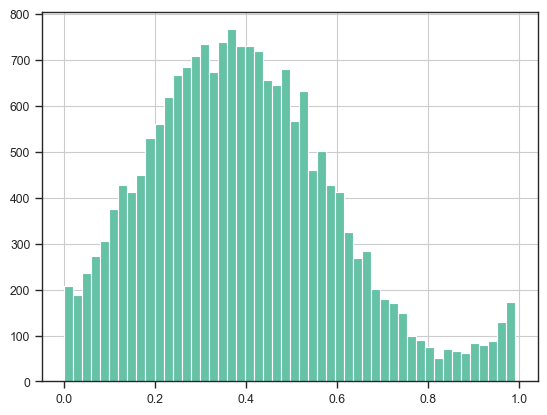

In [73]:
((guide_options_with_vs_without_filter['num_guides_original'] - guide_options_with_vs_without_filter['num_guides_after_filtering'])/guide_options_with_vs_without_filter['num_guides_original']).hist(bins=50)

In [74]:
guide_options_with_vs_without_filter['num_guides_after_filtering'].sum()/guide_options_with_vs_without_filter['num_guides_original'].sum()

0.5660540518013795

<Axes: >

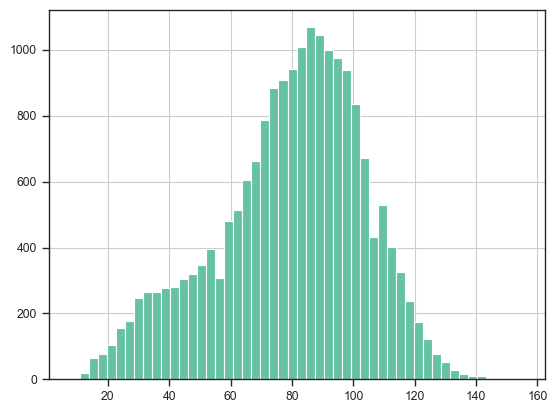

In [40]:
guide_options_with_vs_without_filter['num_guides_original'].hist(bins=50)

<Axes: >

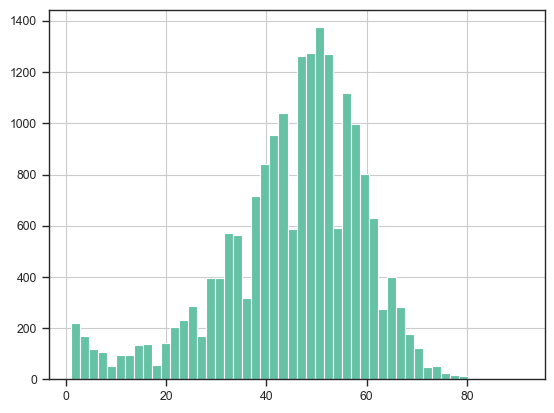

In [43]:
guide_options_with_vs_without_filter['num_guides_after_filtering'].hist(bins=50)

<Axes: xlabel='On-Target Efficacy Score'>

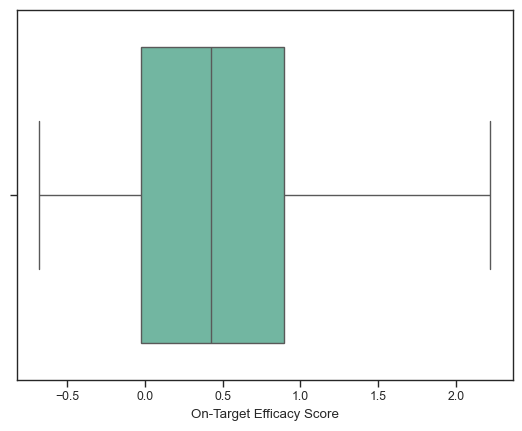

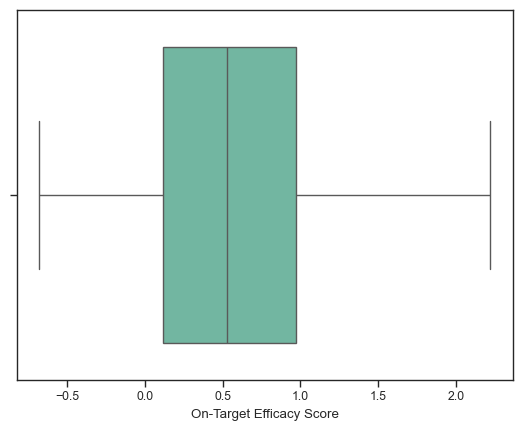

In [47]:
sns.boxplot(x = gw_rs3i_designs['On-Target Efficacy Score'])
plt.figure()
sns.boxplot(x = no_seed_match_designs['On-Target Efficacy Score'])

In [51]:
gw_rs3i_designs[gw_rs3i_designs['On-Target Efficacy Score'] > 1.2].groupby('Target Gene ID')['sgRNA Sequence'].nunique().mean()

10.376482955398709

In [52]:
no_seed_match_designs[no_seed_match_designs['On-Target Efficacy Score'] > 1.2].groupby('Target Gene ID')['sgRNA Sequence'].nunique().mean()

7.207862113962593

In [64]:
no_filter_picked = gw_rs3i_designs[gw_rs3i_designs['Pick Order'] < 4].copy()

In [65]:
no_seed_match_designs['filtered_pick_order'] = no_seed_match_designs.groupby('Target Gene ID')['Pick Order'].transform('rank',method='first')
filter_picked = no_seed_match_designs[no_seed_match_designs['filtered_pick_order'] < 4].copy()

<Axes: >

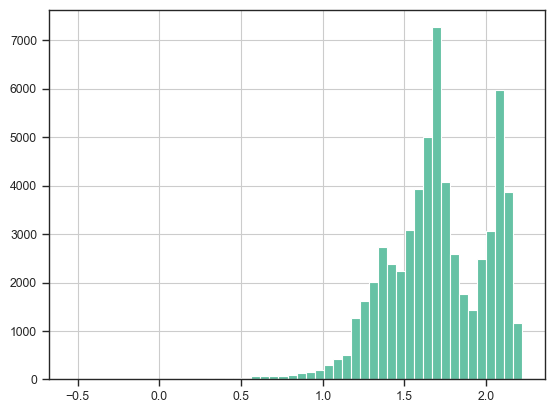

In [66]:
no_filter_picked['On-Target Efficacy Score'].hist(bins=50)

<Axes: >

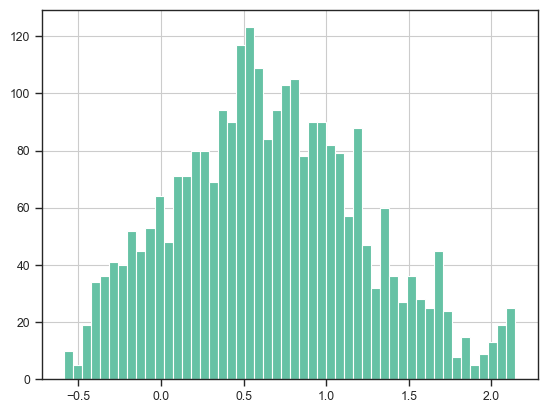

In [67]:
filter_picked['On-Target Efficacy Score'].hist(bins=50)

In [23]:
seed_seq_freq['num_gene'].value_counts()[:20]

3     4143
4     3963
5     3817
2     3816
6     3307
1     2958
7     2953
8     2676
9     2350
10    2152
11    1827
12    1698
13    1588
14    1448
15    1332
16    1162
17    1139
18     978
19     934
20     861
Name: num_gene, dtype: int64

In [ ]:
seed_seq_freq['num_gene'] = np.where(seed_seq_freq['num_gene']>=10,'>=10',seed_seq_freq['num_gene'])

<Axes: xlabel='num_gene', ylabel='Count'>

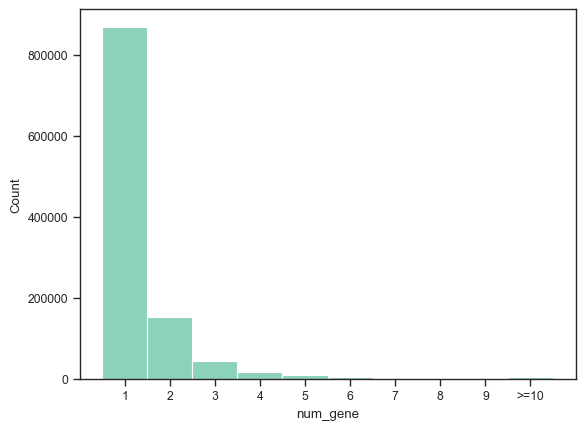

In [16]:
sns.histplot(data = seed_seq_freq, x = 'num_gene')

In [68]:
#goal is to show that filtering based on seed matches is overly conservative
#first problem: there are so many things to decide when thinking about what a "seed match" is
#after defining that (or maybe just repeating the comparison for multiple)...

#if you filter out guides with a seed match, how many are left per gene?
#what does it do to the rs3i scores of guides selected?